In [3]:
from dataloader import open_dataset
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats

In [4]:
import xarray as xr

In [5]:
checkpoint = '2024-03-30_24h_18d28_e011_s049990.nc'
gen_path = '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42'

In [6]:
ds = open_dataset(f'{gen_path}/{checkpoint}').ds

In [7]:
ds

<xarray.Dataset> Size: 933MB
Dimensions:            (Y: 1148, X: 2747, time: 9)
Coordinates:
  * Y                  (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * X                  (X) float64 22kB 0.0 800.0 ... 2.196e+06 2.197e+06
  * time               (time) datetime64[ns] 72B 2024-03-30 ... 2024-03-31
Data variables:
    lat                (Y, X) float32 13MB ...
    lon                (Y, X) float32 13MB ...
    salinity           (time, Y, X) float32 114MB ...
    temperature        (time, Y, X) float32 114MB ...
    u_eastward         (time, Y, X) float32 114MB ...
    v_northward        (time, Y, X) float32 114MB ...
    h                  (time, Y, X) float32 114MB ...
    sea_mask           (time, Y, X) float32 114MB ...
    f                  (time, Y, X) float32 114MB ...
    river_binary_mask  (time, Y, X) float32 114MB ...

In [8]:
#repeat for norkyst
from dataloader_inf import read_norkyst_hindcast_based_on_inferred_nc

In [9]:
#read_norkyst_hindcast_based_on_inferred_nc(f'{checkpoint}', 'norkyst_{year}_{month:02d}_{day:02d}.nc', ['2024-03-30'])

In [10]:
norkyst_gen_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'
norkyst_ceckpoint = 'norkyst800-20240330.nc'

In [11]:
norkyst = open_dataset(f'{norkyst_gen_path}/{norkyst_ceckpoint}', depth = -1).ds

In [12]:
norkyst

<xarray.Dataset> Size: 28GB
Dimensions:           (time: 24, Y: 1148, X: 2747, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-03-30 ... 2024-03-30T23...
    s_rho             float64 8B -0.004904
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 25MB ...
    lat               (Y, X) float64 25MB ...
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 303MB ...
    Vwind_northward   (time, Y, X) float32 303MB ...
    zeta              (time, Y, X) float32 303MB ...
    ubar_eastward     (time, Y, X) float32 303MB ...
    vbar_northward    (time, Y, X) float32 303MB ...
    u_eastward        (time, Y, X) float32 303MB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              float64 8B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 13MB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      15f95603-12d1-4e0f-8cbe-33946594447f
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [13]:
#extract salt
salinity_havbris = ds.salinity.values

In [14]:
norkyst_gen_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'

norkyst_data_path = 'norkyst800-20240330.nc'
norkyst_data_path2 = 'norkyst800-20240331.nc'

norkyst_data_path3 = 'norkyst800-20240401.nc'
norkyst_data_path4 = 'norkyst800-20240402.nc'
norkyst_data_path5 = 'norkyst800-20240403.nc'
norkyst_data_path6 = 'norkyst800-20240404.nc'
norkyst_data_path7 = 'norkyst800-20240405.nc'

norkyst_data_path8 = 'norkyst800-20240406.nc'
norkyst_data_path9 = 'norkyst800-20240407.nc'
norkyst_data_path10 = 'norkyst800-20240408.nc'
norkyst_data_path11 = 'norkyst800-20240409.nc'
norkyst_data_path12 = 'norkyst800-20240410.nc'

norkyst_data_path13 = 'norkyst800-20240411.nc'
norkyst_data_path14 = 'norkyst800-20240412.nc'
norkyst_data_path15 = 'norkyst800-20240413.nc'
norkyst_data_path16 = 'norkyst800-20240414.nc'
norkyst_data_path17 = 'norkyst800-20240415.nc'


In [15]:
var_cut = ['temperature', 'Uwind_eastward', 'zeta', 'Vwind_northward', 'vbar_northward', 'ubar_eastward', 'v_northward', 'u_eastward', 'w', 'ln_AKs', 'hc', 'sea_mask', 'h', 'Cs_r', 'Cs_w']

In [16]:
norkyst_3003 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path}', depth = -1).ds
norkyst_3003 = norkyst_3003.drop_vars(var_cut)
norkyst_3103 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path2}', depth = -1).ds
norkyst_3103 = norkyst_3103.drop_vars(var_cut)

norkyst_0104 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path3}', depth = -1).ds
norkyst_0204 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path4}', depth = -1).ds
norkyst_0304 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path5}', depth = -1).ds
norkyst_0404 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path6}',depth = -1).ds
norkyst_0504 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path7}', depth = -1).ds

norkyst_0604 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path8}', depth = -1).ds
norkyst_0704 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path9}', depth = -1).ds
norkyst_0804 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path10}', depth = -1).ds
norkyst_0904 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path11}', depth = -1).ds
norkyst_1004 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path12}', depth = -1).ds
norkyst_1104 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path13}', depth = -1).ds
norkyst_1204 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path14}', depth = -1).ds
norkyst_1304 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path15}', depth = -1).ds
norkyst_1404 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path16}', depth = -1).ds
norkyst_1504 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path17}', depth = -1).ds

norkyst_0104 = norkyst_0104.drop_vars(var_cut)
norkyst_0204 = norkyst_0204.drop_vars(var_cut)
norkyst_0304 = norkyst_0304.drop_vars(var_cut)
norkyst_0404 = norkyst_0404.drop_vars(var_cut)
norkyst_0504 = norkyst_0504.drop_vars(var_cut)
norkyst_0604 = norkyst_0604.drop_vars(var_cut)
norkyst_0704 = norkyst_0704.drop_vars(var_cut)
norkyst_0804 = norkyst_0804.drop_vars(var_cut)
norkyst_0904 = norkyst_0904.drop_vars(var_cut)
norkyst_1004 = norkyst_1004.drop_vars(var_cut)
norkyst_1104 = norkyst_1104.drop_vars(var_cut)
norkyst_1204 = norkyst_1204.drop_vars(var_cut)
norkyst_1304 = norkyst_1304.drop_vars(var_cut)
norkyst_1404 = norkyst_1404.drop_vars(var_cut)
norkyst_1504 = norkyst_1504.drop_vars(var_cut)


In [17]:
norkyst_3003_daily_mean = norkyst_3003.resample(time = '1D').mean()
norkyst_3103_daily_mean = norkyst_3103.resample(time = '1D').mean()
norkyst_0104_daily_mean = norkyst_0104.resample(time = '1D').mean()
norkyst_0204_daily_mean = norkyst_0204.resample(time = '1D').mean()
norkyst_0304_daily_mean = norkyst_0304.resample(time = '1D').mean()
norkyst_0404_daily_mean = norkyst_0404.resample(time = '1D').mean()
norkyst_0504_daily_mean = norkyst_0504.resample(time = '1D').mean()
norkyst_0604_daily_mean = norkyst_0604.resample(time = '1D').mean()
norkyst_0704_daily_mean = norkyst_0704.resample(time = '1D').mean()
norkyst_0804_daily_mean = norkyst_0804.resample(time = '1D').mean()
norkyst_0904_daily_mean = norkyst_0904.resample(time = '1D').mean()
norkyst_1004_daily_mean = norkyst_1004.resample(time = '1D').mean()
norkyst_1104_daily_mean = norkyst_1104.resample(time = '1D').mean()
norkyst_1204_daily_mean = norkyst_1204.resample(time = '1D').mean()
norkyst_1304_daily_mean = norkyst_1304.resample(time = '1D').mean()
norkyst_1404_daily_mean = norkyst_1404.resample(time = '1D').mean()
norkyst_1504_daily_mean = norkyst_1504.resample(time = '1D').mean()

In [18]:
ds_t = [norkyst_3003_daily_mean,
norkyst_3103_daily_mean,
norkyst_0104_daily_mean,
norkyst_0204_daily_mean,
norkyst_0304_daily_mean,
norkyst_0404_daily_mean,
norkyst_0504_daily_mean,
norkyst_0604_daily_mean,
norkyst_0704_daily_mean,
norkyst_0804_daily_mean,
norkyst_0904_daily_mean,
norkyst_1004_daily_mean,
norkyst_1104_daily_mean,
norkyst_1204_daily_mean,
norkyst_1304_daily_mean,
norkyst_1404_daily_mean,
norkyst_1504_daily_mean]

In [19]:
ds_n = xr.concat(ds_t, dim = 'time')

In [20]:
ds_n

<xarray.Dataset> Size: 265MB
Dimensions:           (time: 17, Y: 1148, X: 2747, s_w: 41)
Coordinates:
    s_rho             float64 8B -0.004904
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 25MB 8.7 8.706 8.711 ... 18.29 18.31 18.33
    lat               (Y, X) float64 25MB 54.29 54.3 54.31 ... 75.71 75.72 75.73
  * time              (time) datetime64[ns] 136B 2024-03-30 ... 2024-04-15
Data variables:
    salinity          (time, Y, X) float32 214MB nan nan nan ... 34.41 34.42
    projection_stere  (time) float64 136B -2.147e+09 -2.147e+09 ... -2.147e+09
    depth             (time) float64 136B -2.147e+09 -2.147e+09 ... -2.147e+09
Attributes: (12/33)
    id:                      15f95603-12d1-4e0f-8cbe-33946594447f
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [21]:
salinity_climatology = ds_n['salinity'].groupby('time.day').mean(dim = 'time')

In [22]:
anomalies = ds_n.salinity - salinity_climatology

In [23]:
anomalies

<xarray.DataArray 'salinity' (time: 17, Y: 1148, X: 2747, day: 17)> Size: 4GB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 1.37710571e-03,  7.05718994e-04,  6.21795654e-04, ...,
          -1.56669617e-02,  0.00000000e+00,  1.79290771e-03],
         [ 1.82723999e-03,  1.70135498e-03,  1.37329102e-03, ...,
          -1.58729553e-02,  0.00000000e+00,  2.33078003e-03],
         [-1.12915039e-03, -3.00216675e-03, -3.75366211e-03, ...,
          -1.69601440e-02,  0.00000000e+00,  1.08337402e-03]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
           0.00000000e+00,  1.64249420e-01,  1.67415619e-01],
         [ 1.62960052e-01,  1.60293579e-01,  1.21456146e-01, ...,
           0.00000000e+00,  1.56074524e-01,  1.59626007e-01],
         [ 1.37294769e-01,  1.35295868e-01,  1.06918335e-01, ...,
           0.00000000e+00,  1.31000519e-01,  1.34002686e-01]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 1.27540588e-01,  1.21166229e-01,  8.59184265e-02, ...,
           0.00000000e+00,  1.24332428e-01,  1.26251221e-01],
         [ 1.28456116e-01,  1.24710083e-01,  9.38758850e-02, ...,
           0.00000000e+00,  1.23626709e-01,  1.26045227e-01],
         [ 1.32789612e-01,  1.29955292e-01,  1.00330353e-01, ...,
           0.00000000e+00,  1.27204895e-01,  1.29997253e-01]]]],
      shape=(17, 1148, 2747, 17), dtype=float32)
Coordinates:
    s_rho    float64 8B -0.004904
  * X        (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y        (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.16e+05 9.168e+05 9.176e+05
    lon      (Y, X) float64 25MB 8.7 8.706 8.711 8.717 ... 18.29 18.31 18.33
    lat      (Y, X) float64 25MB 54.29 54.3 54.31 54.31 ... 75.71 75.72 75.73
  * time     (time) datetime64[ns] 136B 2024-03-30 2024-03-31 ... 2024-04-15
  * day      (day) int64 136B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 30 31

In [24]:
import seaborn as sns 

In [25]:
#random_day = anomalies.isel(time = 0, day = 0)

In [26]:
#sns.histplot(random_day, bins = 50)

(array([5.4000000e+01, 2.1500000e+02, 5.5300000e+02, 1.4440000e+03,
        3.3420000e+03, 7.6320000e+03, 6.1833000e+04, 1.9949800e+05,
        9.3861500e+05, 8.5233638e+07, 9.8099612e+07, 1.0196940e+06,
        2.4693700e+05, 7.9099000e+04, 1.1494000e+04, 4.7500000e+03,
        2.0820000e+03, 8.2800000e+02, 3.3000000e+02, 7.8000000e+01]),
 array([-30.69483566, -27.62535286, -24.55586815, -21.48638535,
        -18.41690063, -15.34741783, -12.27793503,  -9.20845032,
         -6.13896751,  -3.06948471,   0.        ,   3.06948471,
          6.13896561,   9.20845032,  12.27793503,  15.34741592,
         18.41690063,  21.48638535,  24.55586624,  27.62535095,
         30.69483566]),
 <BarContainer object of 20 artists>)

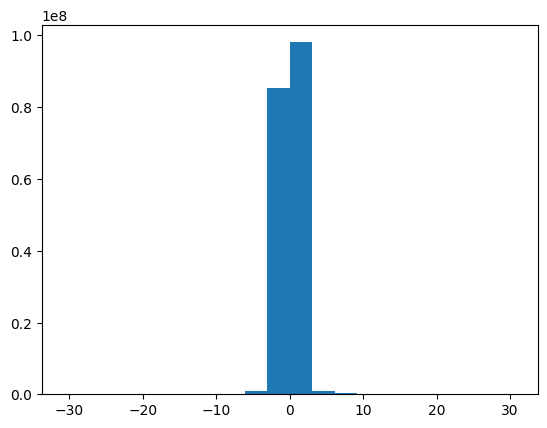

In [28]:
subsampled_anomalies = anomalies.isel(time=slice(0, None, 3))
flattened_data = subsampled_anomalies.values.flatten()
flattened_data = flattened_data[~np.isnan(flattened_data)]
plt.hist(flattened_data, bins=20)

<Axes: ylabel='Density'>

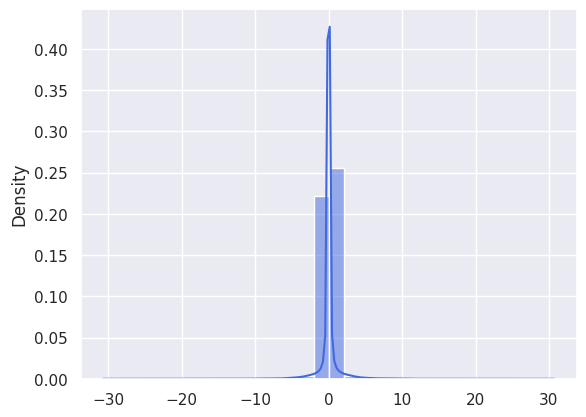

In [31]:
sns.set_theme(style='darkgrid')
sns.histplot(flattened_data, bins = 30, kde = True, stat = 'density', color = 'royalblue')